## How to count tokens

In [ ]:
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.2 MB/s eta 0:00:00


In [ ]:
import tiktoken

# Input teks
text = "Halo, saya sedang belajar LLM"
encoding = tiktoken.encoding_for_model("gpt-3.5-turbo")

# Menghitung jumlah token dari text
tokens = encoding.encode(text)
print("Number of tokens:", len(tokens))
print(tokens)

# Decode setiap token
decoded_tokens = [encoding.decode([token]) for token in tokens]

# Decode keseluruhan array token
decoded_text = encoding.decode(tokens)

print("Decoded Tokens:", decoded_tokens)
print("Decoded Text:", decoded_text)

Number of tokens: 10
[39, 12812, 11, 55037, 11163, 526, 1689, 52004, 445, 11237]
Decoded Tokens: ['H', 'alo', ',', ' saya', ' sed', 'ang', ' bel', 'ajar', ' L', 'LM']
Decoded Text: Halo, saya sedang belajar LLM


Classifying a text as positive or negative

In [ ]:
import getpass
import requests
import json
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# Fungsi untuk berinteraksi dengan LLM Telkom
def ask_telkom_llm(assistant_prompt, user_question):

    # API_KEY = getpass.getpass("Enter your API Key: ")
    API_KEY = "iofnCY55Xti07jwRQewqcnaDK3GRufDH"
    POST_URL = "https://telkom-ai-dag-api.apilogy.id/Telkom-LLM/0.0.4/llm/chat/completions"

    headers = {
        'accept': 'application/json',
        'x-api-key': API_KEY,
        'Content-Type': 'application/json',
    }

    json_data = {
        'headers': {},
        'messages': [
            {
                'role': 'assistant',
                'content': str(assistant_prompt),
            },
            {
                'role': 'user',
                'content': str(user_question),
            },
        ],
        'temperature': 0,
    }

    response = requests.post(POST_URL, headers=headers, json=json_data)

    if response.status_code == 200:
        return json.loads(response.text)['choices'][0]['message']['content']
    else:
        raise Exception(f"LLM API Error: {response.status_code}, {response.text}")

# Sampel data X dan Y untuk NLP Tradisional
data = [
    ("Ini adalah review bagus tentang makanan ini", "positif"),
    ("Saya benci produk ini", "negatif"),
    ("Layanannya sangat luar biasa", "positif"),
    ("Pengalaman mengerikan, sangat buruk", "negatif"),
    ("Saya suka ini, saya akan beli lagi", "positif"),
    ("Terlalu mahal, tidak sebanding dengan harga", "negatif")
]

# Persiapan data train dan test untuk NLP
texts, labels = zip(*data)
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Fungsi NLP Tradisional dengan TF-IDF + Naive Bayes
def traditional_nlp_classifier(train_texts, train_labels, test_texts):
    model = make_pipeline(TfidfVectorizer(), MultinomialNB())
    model.fit(train_texts, train_labels)
    predictions = model.predict(test_texts)
    return predictions

# Fungsi LLM untuk tugas klasifikasi
def llm_classifier(prompt, text):
    try:
        return ask_telkom_llm(prompt, text)
    except Exception as e:
        print("LLM Error:", e)
        return None

# Tugas untuk NLP dan LLM : Memprediksi apa kalimat berikut memiliki sentimen positif atau negatif
sentence_to_classify = "Saya tidak suka nasi goreng"

# 1. LLM Telkom
llm_prompt = "Tolong klasifikasikan apa teks ini memiliki sentimen positif atau negatif. Format jawaban hanya positif atau negatif.:"
llm_prediction = llm_classifier(llm_prompt, sentence_to_classify)
print(f"{llm_prompt}")
print(f"Prediksi LLM: {llm_prediction}")

# 2. NLP Tradisional
traditional_predictions = traditional_nlp_classifier(X_train, y_train, [sentence_to_classify])
print(f"Prediksi NLP Tradisional: {traditional_predictions[0]}")




Tolong klasifikasikan apa teks ini memiliki sentimen positif atau negatif. Format jawaban hanya positif atau negatif.:
Prediksi LLM: negatif
Prediksi NLP Tradisional: positif


# Prompting Techniques

In [ ]:
task_description = "Explain the concept of gravity in simple terms."

## Zero Shot Prompting

In [ ]:
# 1. Zero-Shot Prompting
print("### Zero-Shot Prompting ###")
zero_shot_prompt = task_description
zero_shot_response = ask_telkom_llm("Zero Shot", zero_shot_prompt)
print(f"Response: {zero_shot_response}\n")

### Zero-Shot Prompting ###
Response: Sure! Gravity is a fundamental force of nature that causes objects with mass to attract each other. In simple terms, it's like an invisible string that pulls things together. 

Imagine you drop a ball. What happens? It falls to the ground. That's gravity at work! The Earth has a lot of mass, and because of this, it pulls everything towards its center. This is why objects fall down instead of floating away.

Gravity is what keeps our feet on the ground, keeps the planets in orbit around the sun, and even holds galaxies together. It's always trying to pull things closer, but the strength of this pull depends on how much mass the objects have and how close they are to each other.



## Few-Shot Prompting

In [ ]:
# 2. Few-Shot Prompting
print("### Few-Shot Prompting ###")
few_shot_prompt = (
        "Example 1: Explain photosynthesis:\n"
        "Photosynthesis is the process by which plants make their own food using sunlight, water, and carbon dioxide.\n\n"
        "Example 2: Explain the water cycle:\n"
        "The water cycle describes how water moves through evaporation, condensation, and precipitation.\n\n"
        f"Now, {task_description}"
)

few_shot_response = ask_telkom_llm("Few Shot", few_shot_prompt)
print(f"Response: {few_shot_response}\n")

### Few-Shot Prompting ###
Response: Gravity is the force that pulls objects toward each other. On Earth, it's what keeps you on the ground and causes things to fall when you drop them. Essentially, gravity is always trying to pull you and everything around you down toward the center of the Earth.



## Chain-of-Thought (CoT) Prompting



In [ ]:
# 3. Chain-of-Thought (CoT) Prompting
print("### Chain-of-Thought (CoT) Prompting ###")
cot_prompt = (
        f"{task_description}\n"
        "Let's break this down step by step:\n"
        "1. Gravity is a force of attraction.\n"
        "2. It pulls objects toward each other.\n"
        "3. The strength of gravity depends on the mass of the objects and the distance between them.\n"
        "Explain in your own words:"
)
cot_response = ask_telkom_llm("CoT", cot_prompt)
print(f"Response: {cot_response}\n")

### Chain-of-Thought (CoT) Prompting ###
Response: Sure! Let's break down the concept of gravity in simple terms:

1. **Gravity is a force of attraction**: Imagine you have a ball. This ball has a special kind of invisible string that pulls on other objects. This pulling force is what we call gravity.

2. **It pulls objects toward each other**: When you drop a ball, it falls to the ground. That's because the Earth is pulling the ball down with its gravity. Similarly, the ball also pulls the Earth a tiny bit, but since the Earth is so much bigger, we don't notice it.

3. **The strength of gravity depends on the mass of the objects and the distance between them**: The more massive an object is, the stronger its gravitational pull. For example, the Earth is much more massive than you, so it has a much stronger gravitational pull. The distance between objects also matters; the closer two objects are, the stronger the gravitational pull between them. If you were to move far away from the Ea

## Tree-of-Thought (ToT) Prompting

In [ ]:
# 4. Tree-of-Thought (ToT) Prompting
print("### Tree-of-Thought (ToT) Prompting ###")
tot_prompt = (
        f"{task_description}\n"
        "Let's generate multiple explanations and evaluate:\n"
        "Option 1: Gravity keeps planets orbiting the sun.\n"
        "Option 2: Gravity makes objects fall to the ground.\n"
        "Option 3: Gravity holds everything together in the universe.\n"
        "Choose the best explanation:"
)
tot_response = ask_telkom_llm("ToT", tot_prompt)
print(f"Response: {tot_response}\n")

### Tree-of-Thought (ToT) Prompting ###
Response: All three options touch on different aspects of gravity, but let's evaluate them to see which one provides the most comprehensive understanding:

Option 1: "Gravity keeps planets orbiting the sun."
- This is a specific example of gravity's effect, focusing on the solar system. It's accurate but limited in scope.

Option 2: "Gravity makes objects fall to the ground."
- This is another specific example, focusing on the Earth's surface. It's also accurate but doesn't capture the full range of gravity's influence.

Option 3: "Gravity holds everything together in the universe."
- This is the most comprehensive explanation. It encompasses the gravitational forces that affect everything from subatomic particles to galaxies, making it the best choice for a general understanding of gravity.

The best explanation is Option 3: "Gravity holds everything together in the universe." This statement captures the essence of gravity as a fundamental force

## Ensembling Prompt

In [ ]:
# 5. Ensembling
print("### Ensembling ###")
ensembling_prompt = (
        f"{task_description}\n"
        "Provide two different explanations then aggregating these explanations into a final explanation:\n"
        "1. Gravity is a force that pulls objects toward each other.\n"
        "2. Gravity is what makes things fall and keeps planets in orbit."
)
ensembling_response = ask_telkom_llm("Ensembling", ensembling_prompt)
print(f"Response: {ensembling_response}\n")

### Ensembling ###
Response: Certainly! Let's break down the concept of gravity using the two explanations you provided and then combine them into a final, comprehensive explanation.

1. **Gravity as a Force that Pulls Objects Toward Each Other:**
   Gravity is a fundamental force in the universe that causes objects with mass to attract one another. This means that any two objects, no matter how small, exert a pulling force on each other. The strength of this force depends on the mass of the objects and the distance between them. For example, the Earth and the Moon are attracted to each other due to gravity, which keeps the Moon in orbit around the Earth.

2. **Gravity as What Makes Things Fall and Keeps Planets in Orbit:**
   Gravity is the reason why objects fall to the ground when dropped and why planets move in orbits around the Sun. When you drop an object, it falls toward the ground because the Earth's gravity pulls it down. Similarly, planets orbit the Sun because the Sun's grav

## Self-Criticism Prompting

In [ ]:
# 6. Self-Criticism
print("### Self-Criticism ###")
self_criticism_prompt = (
        f"{task_description}\n"
        "Here is my first explanation:\n"
        "Gravity is the force that pulls everything down.\n"
        "What could be improved in this explanation? Provide a better version."
)
self_criticism_response = ask_telkom_llm("Self-Criticism", self_criticism_prompt)
print(f"Response: {self_criticism_response}\n")

### Self-Criticism ###
Response: Your explanation is a good starting point, but it could be improved to provide a more accurate and comprehensive understanding of gravity. Here's a better version:

"Gravity is the force that attracts any two masses in the universe towards each other. It pulls everything down towards the center of mass, which is why objects fall to the ground when dropped. This force is what keeps our feet on the Earth and the planets in orbit around the Sun."

This version clarifies that gravity acts between any masses, not just between an object and the Earth, and it also explains why objects fall towards the center of mass.



## Decomposition Prompting

In [ ]:
# 7. Decomposition
print("### Decomposition ###")
decomposition_prompt = (
        f"{task_description}\n"
        "Break the explanation into smaller parts:\n"
        "1. What is gravity?\n"
        "2. Why is it important?\n"
        "3. How does it work?\n"
        "Provide answers for each question:"
)
decomposition_response = ask_telkom_llm("Decomposition", decomposition_prompt)
print(f"Response: {decomposition_response}\n")

### Decomposition ###
Response: Sure, let's break down the concept of gravity into simpler parts:

1. **What is gravity?**
   Gravity is a fundamental force of nature that attracts any two objects with mass towards each other. It is the force that causes objects to fall towards the ground when dropped and keeps the planets in orbit around the sun.

2. **Why is it important?**
   Gravity is crucial for many aspects of our daily lives and the functioning of the universe. It is responsible for the formation and stability of planets, stars, and galaxies. It also affects how objects move and interact with each other, influencing everything from the trajectory of a thrown ball to the orbits of satellites.

3. **How does it work?**
   Gravity works by causing objects with mass to exert a pull on each other. The strength of this pull depends on the masses of the objects and the distance between them. The more massive an object is, the stronger its gravitational pull. The closer two objects are

## Embedding Concept & Vector Database

In [ ]:
!pip install qdrant-client sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.6/306.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 25.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.5
    Uninstalling protobuf-4.25.5:
      Successfully uninstalled protobuf-4.25.5
  Attempting uninstall: grpcio
    Found existing installation: grpcio 1.69.0
    Uninstalling grpcio-1.69.0:
      Successfully uninstalled grpcio-1.69.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.17.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but 

In [ ]:
from qdrant_client import QdrantClient
from qdrant_client.models import PointStruct, Distance, VectorParams, FieldCondition, MatchValue
from sentence_transformers import SentenceTransformer

# Initialize the embedding model (Sentence Transformers)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Sample sentences
sentences = [
    "Kecerdasan Buatan (Artificial Intelligence) semakin berkembang di Telkom Indonesia.",
    "Machine Learning digunakan oleh Telkom untuk meningkatkan efisiensi operasional.",
    "Deep learning memungkinkan Telkom untuk memahami pola data lebih mendalam.",
    "Pemrosesan Bahasa Alami (Natural Language Processing) digunakan dalam layanan pelanggan Telkom.",
    "Embeddings vektor digunakan oleh Telkom untuk analisis data pelanggan secara lebih efektif."
]

# Generate embeddings for the sentences
embeddings = embedding_model.encode(sentences)

print(embeddings.shape)
print(embeddings[0])
print(embeddings[0].shape)

In [ ]:
# Connect to Qdrant
client = QdrantClient(":memory:")
collection_name = "digicamp_embeddings"

# Create a collection in Qdrant
client.recreate_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(size=len(embeddings[0]), distance=Distance.COSINE),
)

# Insert embeddings into Qdrant
points = [
    PointStruct(
        id=i,
        vector=embeddings[i],
        payload={"sentence": sentences[i]}
    )
    for i in range(len(sentences))
]

client.upsert(collection_name=collection_name, points=points)

# Query Qdrant for nearest similarity
query_sentence = "Aplikasi di Telkom menggunakan Artificial Intelligence"
query_vector = embedding_model.encode([query_sentence])[0]

search_results = client.search(
    collection_name=collection_name,
    query_vector=query_vector,
    limit=3  # Retrieve top 3 most similar sentences
)


<ipython-input-59-c736fd961b89>:6: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(
<ipython-input-59-c736fd961b89>:27: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  search_results = client.search(


In [ ]:
# Display results
print(f"Query Sentence: {query_sentence}")
print("Top 3 Similar Sentences:")
for result in search_results:
    print(f" - {result.payload['sentence']} (Score: {result.score:.4f})")

Query Sentence: Aplikasi di Telkom menggunakan Artificial Intelligence
Top 3 Similar Sentences:
 - Kecerdasan Buatan (Artificial Intelligence) semakin berkembang di Telkom Indonesia. (Score: 0.8099)
 - Machine Learning digunakan oleh Telkom untuk meningkatkan efisiensi operasional. (Score: 0.6901)
 - Deep learning memungkinkan Telkom untuk memahami pola data lebih mendalam. (Score: 0.5898)


## Retrieval Augmented Transformer (RAG) from PDF documents

In [ ]:
!pip install PyMuPDF

In [ ]:
from qdrant_client import QdrantClient
from qdrant_client.models import PointStruct, Distance, VectorParams, FieldCondition, MatchValue
from sentence_transformers import SentenceTransformer
import fitz

# Initialize the embedding model (Sentence Transformers)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Fungsi untuk mengambil kalimat dari PDF
def extract_sentences_from_pdf(pdf_path):
    doc = fitz.open(pdf_path)  # Membuka file PDF
    sentences = []

    # Menyusuri setiap halaman dalam PDF
    for page_num in range(len(doc)):
        page = doc.load_page(page_num)  # Memuat halaman ke-`page_num`
        text = page.get_text("text")  # Ekstrak teks dalam bentuk string
        page_sentences = text.split('.')  # Pisahkan teks menjadi kalimat-kalimat berdasarkan tanda titik

        # Membersihkan dan menambahkan kalimat yang valid
        for sentence in page_sentences:
            clean_sentence = sentence.strip()
            if clean_sentence:
                sentences.append(clean_sentence)

    return sentences

# Path ke file PDF
pdf_path = "/content/Katalog-Produk-Telkom-Digital-Solution-2022.pdf"

# Ambil kalimat-kalimat dari PDF
sentences = extract_sentences_from_pdf(pdf_path)

# Print beberapa kalimat yang diambil dari PDF (untuk memastikan)
# print("Kalimat-kalimat yang diambil dari PDF:")
# for sentence in sentences[:5]:
#     print(sentence)

# Generate embeddings untuk kalimat-kalimat yang diambil
embeddings = embedding_model.encode(sentences)


In [ ]:
# Connect to Qdrant
client = QdrantClient(":memory:")
collection_name = "digicamp_embeddings"

# Create a collection in Qdrant
client.recreate_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(size=len(embeddings[0]), distance=Distance.COSINE),
)

# Insert embeddings into Qdrant
points = [
    PointStruct(
        id=i,
        vector=embeddings[i],
        payload={"sentence": sentences[i]}
    )
    for i in range(len(sentences))
]

client.upsert(collection_name=collection_name, points=points)

# Query Qdrant for nearest similarity
query_sentence = "Produk yang berkaitan profil pelanggan dan mencegah fraud"
query_vector = embedding_model.encode([query_sentence])[0]

search_results = client.search(
    collection_name=collection_name,
    query_vector=query_vector,
    limit=3  # Retrieve top 3 most similar sentences
)


<ipython-input-65-7eea3fd55db8>:6: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(
<ipython-input-65-7eea3fd55db8>:27: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  search_results = client.search(


In [ ]:
# Display results
print(f"Query Sentence: {query_sentence}")
print("Top 3 Similar Sentences:")
for result in search_results:
    print(f" - {result.payload['sentence']} (Score: {result.score:.4f})")

Query Sentence: Produk yang berkaitan profil pelanggan dan mencegah fraud
Top 3 Similar Sentences:
 - Secara umum, proses yang dilakukan adalah mengumpulkan profil dan 
informasi pelanggan yang kemudian di evaluasi untuk mencari tahu apakah ada 
potensi fraud (Score: 0.8237)
 - •	
Mengurangi fraud karena semua 
proses & transaksi tercatat secara 
sistem (Score: 0.7305)
 - •	
Meminimalisir biaya pengelolaan 
dan resiko fraud cash management (Score: 0.7219)


# Tanyakan model dengan pengetahuan yang didapat dari pdf document

In [ ]:
def query_product_info(query, collection_name):
    # Generate embedding untuk query pengguna
    query_embedding = embedding_model.encode(query)

    # Mencari kalimat yang paling relevan di Qdrant berdasarkan vektor query
    search_result = client.search(
        collection_name=collection_name,
        query_vector=query_embedding.tolist(),
        limit=1,  # Mengambil satu hasil paling relevan
        # distance=Distance.COSINE
    )

    # Mengambil kalimat dari hasil pencarian
    most_similar_sentence = search_result[0].payload['sentence']
    similarity_score = search_result[0].score

    return most_similar_sentence, similarity_score

In [ ]:
# Pertanyaan dari pengguna (query)
user_query = "Jelaskan solusi Big Data Telkom"

# Menjalankan pencarian berdasarkan query
answer, score = query_product_info(user_query, collection_name)

# Menampilkan hasil
print(f"Jawaban untuk query '{user_query}':")
print(f"Kalimat terkait: {answer}")
print(f"Skor kemiripan: {score:.4f}")

Jawaban untuk query 'Jelaskan solusi Big Data Telkom':
Kalimat terkait: Katalog Produk Telkom Digital Solution 2022
18
BIG DATA INSIGHT	
BIG DATA PLATFORM	
Big Data Insight memungkinkan perusahaan mendapatkan informasi mendalam 
atau insight yang dapat membantu proses pengambilan keputusan melalui 
pengolahan data yang berukuran sangat besar, sangat variatif, sangat cepat 
pertumbuhannya, dan mungkin tidak terstruktur (big data analytics)
Skor kemiripan: 0.7822


<ipython-input-71-728a4cb080a1>:6: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  search_result = client.search(


## Self Attention Mechanism

In [ ]:
!pip install matplotlib numpy transformers torch

Attention Weights:
 [[9.4035470e-01 6.7178868e-03 2.3336019e-03 ... 9.3792251e-04
  2.8913876e-03 4.2733891e-04]
 [1.0698765e-03 8.3590806e-01 2.1012707e-03 ... 6.1235618e-04
  7.5051206e-04 1.1186644e-04]
 [8.5104891e-04 4.8118168e-03 8.9177775e-01 ... 3.2372749e-03
  1.2995034e-03 2.5348400e-04]
 ...
 [6.2409374e-05 2.5585038e-04 5.9065584e-04 ... 9.4443631e-01
  1.5169514e-03 6.5326225e-05]
 [3.8688275e-04 6.3056516e-04 4.7678512e-04 ... 3.0504372e-03
  9.1807485e-01 2.0838121e-04]
 [2.3308567e-04 3.8312649e-04 3.7911045e-04 ... 5.3548563e-04
  8.4943167e-04 9.8922545e-01]]

Self-Attention Output:
 [[-0.20877253  0.10407276 -0.3861984  ...  0.0381272   0.24261914
   0.48797512]
 [ 1.8878052  -0.30284643  0.28930795 ...  0.10292798  1.6843475
   1.4779459 ]
 [-0.05022991 -0.687118   -0.76362914 ... -0.17005819  0.8090172
   0.61605877]
 ...
 [ 0.77988964  0.17034124 -1.5923656  ... -1.4968561  -1.0841489
  -0.10274228]
 [ 0.15014158 -0.32176816 -0.9696803  ... -0.00904467 -0.11416554

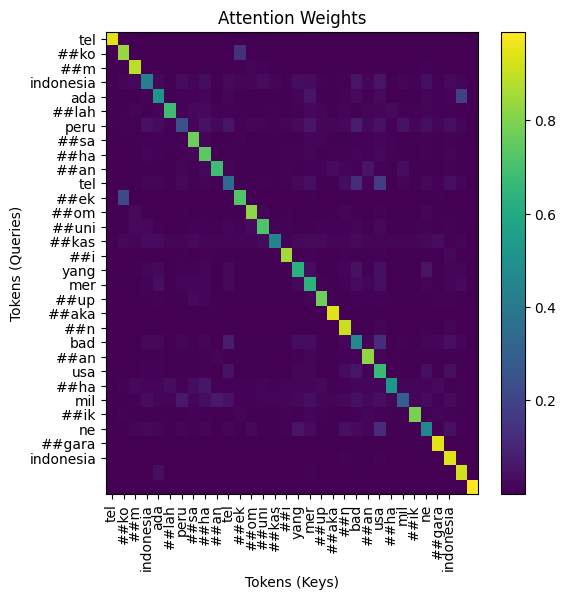

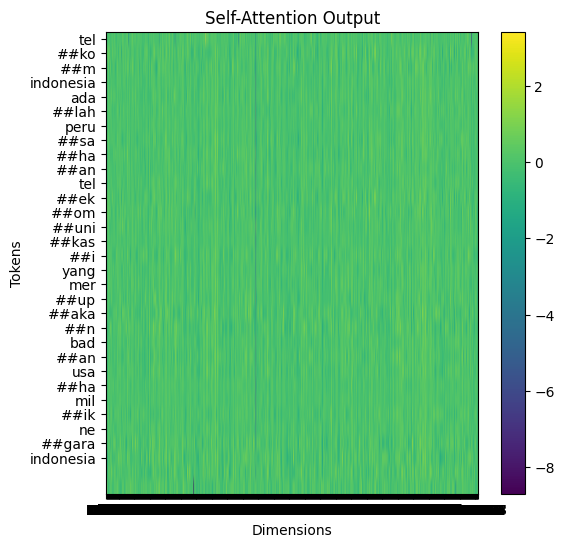

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
import torch

# Define self-attention calculation function
def self_attention(Q, K, V):
    # Calculate the attention scores (Q * K.T)
    attention_scores = np.dot(Q, K.T)

    # Scale the attention scores by the square root of the dimension of the key
    d_k = K.shape[-1]  # dimension of the key
    attention_scores /= np.sqrt(d_k)

    # Apply softmax to get attention weights
    attention_weights = softmax(attention_scores)

    # Multiply attention weights by the value matrix
    output = np.dot(attention_weights, V)

    return attention_weights, output

# Softmax Function
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))  # For numerical stability
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

# Function to plot attention weights
def plot_attention_weights(weights, tokens):
    plt.figure(figsize=(6, 6))
    plt.imshow(weights, cmap='viridis', aspect='auto')
    plt.colorbar()
    plt.title("Attention Weights")
    plt.xlabel("Tokens (Keys)")
    plt.ylabel("Tokens (Queries)")
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.yticks(range(len(tokens)), tokens)
    plt.show()

# Function to plot the self-attention output
def plot_output(output, tokens):
    plt.figure(figsize=(6, 6))
    plt.imshow(output, cmap='viridis', aspect='auto')
    plt.colorbar()
    plt.title("Self-Attention Output")
    plt.xlabel("Dimensions")
    plt.ylabel("Tokens")
    plt.xticks(range(output.shape[1]), [f"Dim {i+1}" for i in range(output.shape[1])])
    plt.yticks(range(len(tokens)), tokens)
    plt.show()

# Tokenize the input sentence
sentence = "Telkom Indonesia adalah perusahaan telekomunikasi yang merupakan badan usaha milik negara Indonesia"

# Initialize the tokenizer (BERT tokenizer is fine for this demonstration)
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokens = tokenizer.tokenize(sentence)

# Convert tokens to embeddings using BERT (this is just for illustration)
model = AutoModel.from_pretrained('bert-base-uncased')
inputs = tokenizer(sentence, return_tensors="pt")
with torch.no_grad():
    embeddings = model(**inputs).last_hidden_state.squeeze(0).numpy()

# Use the first layer of the BERT model for Q, K, and V matrices (for simplicity)
Q = embeddings  # Queries
K = embeddings  # Keys
V = embeddings  # Values

# Apply self-attention
attention_weights, output = self_attention(Q, K, V)

# Displaying attention weights and output
print("Attention Weights:\n", attention_weights)
print("\nSelf-Attention Output:\n", output)

# Plot the attention weights and the output
plot_attention_weights(attention_weights, tokens)
plot_output(output, tokens)


## Transformer Architecture

In [ ]:
!pip install matplotlib numpy transformers torch

Output Shape (after squeeze): torch.Size([5, 8])


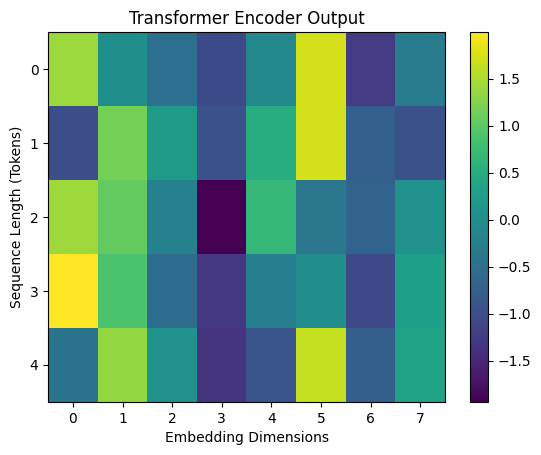

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Define a simple Transformer Encoder Layer
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super(TransformerEncoderLayer, self).__init__()
        self.self_attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, dropout=dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Self-attention
        attn_output, _ = self.self_attention(x, x, x)
        x = self.layer_norm1(x + self.dropout(attn_output))  # Add & Norm

        # Feed Forward Network
        ffn_output = self.ffn(x)
        x = self.layer_norm2(x + self.dropout(ffn_output))  # Add & Norm
        return x

# Generate random input (sequence of tokens, each with d_model dimensions)
sequence_length = 5  # Number of tokens in the sequence
d_model = 8  # Dimension of each token embedding
n_heads = 2  # Number of attention heads
d_ff = 16  # Dimension of the feed-forward layer
batch_size = 1  # Just one example

# Create a random sequence of embeddings (e.g., word embeddings)
x = torch.rand(sequence_length, batch_size, d_model)

# Create the Transformer Encoder layer
encoder_layer = TransformerEncoderLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff)

# Forward pass through the encoder layer
output = encoder_layer(x)

# Squeeze the batch dimension
output_squeezed = output.squeeze(1)  # This will change the shape to [5, 8]

# Visualize the output
print(f"Output Shape (after squeeze): {output_squeezed.shape}")
plt.imshow(output_squeezed.detach().numpy(), cmap='viridis', aspect='auto')
plt.colorbar()
plt.title("Transformer Encoder Output")
plt.xlabel("Embedding Dimensions")
plt.ylabel("Sequence Length (Tokens)")
plt.show()



## Differences Between GPT, BERT, and T5 Architectures

# GPT (Decoder-only)

In [ ]:
import torch
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# Initialize the GPT-2 model and tokenizer (GPT is a variant of Transformer Decoder)
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')  # Use GPT2LMHeadModel for language modeling

# Input text
input_text = "Saya senang belajar LLM"

# ===== Step 1: Tokenization (Input Sequence) =====
inputs = tokenizer(input_text, return_tensors="pt")

# Display tokenized input
print("===== Step 1: Tokenized Input =====")
print(f"Tokenized input IDs: {inputs['input_ids']}")  # Token IDs
print(f"Decoded input text: {tokenizer.decode(inputs['input_ids'][0])}")  # Decoded text

# ===== Step 2: Embedding Layer =====
# Token IDs are passed through the embedding layer to get embeddings
embedding_layer_output = model.transformer.wte(inputs['input_ids'])

# Display embedding output shape (Embedding vectors)
print("\n===== Step 2: Embedding Layer Output =====")
print(f"Embedding output shape: {embedding_layer_output.shape}")

# ===== Step 3: Decoder Blocks (Passing through GPT's Decoder Layers) =====
# Note that model returns tuple (logits, past_key_values, hidden_states) when output_hidden_states=True
outputs = model(**inputs, output_hidden_states=True)  # Set output_hidden_states=True to access hidden states

# The hidden states are returned as a tuple of (layers x batch x seq_len x dim)
hidden_states = outputs.hidden_states

# Take the hidden state from the last decoder block
decoder_output = hidden_states[-1]  # The last layer hidden states

# Display decoder output shape
print("\n===== Step 3: Decoder Block Output =====")
print(f"Decoder output shape (from last block): {decoder_output.shape}")

# ===== Step 4: Output Token Prediction =====
# Finally, we get the logits and predict the next token using the final decoder output
logits = model.lm_head(decoder_output)  # Language model head (output layer)
predicted_token_id = torch.argmax(logits[:, -1, :], dim=-1)  # Predicted next token ID
predicted_token = tokenizer.decode(predicted_token_id)  # Decode predicted token ID

# Display the predicted token
print("\n===== Step 4: Predicted Token =====")
print(f"Predicted next token: {predicted_token}")


===== Step 1: Tokenized Input =====
Tokenized input IDs: tensor([[   50, 11729,  3308,   648,   894,  1228,   283, 27140,    44]])
Decoded input text: Saya senang belajar LLM

===== Step 2: Embedding Layer Output =====
Embedding output shape: torch.Size([1, 9, 768])

===== Step 3: Decoder Block Output =====
Decoder output shape (from last block): torch.Size([1, 9, 768])

===== Step 4: Predicted Token =====
Predicted next token: ,


# BERT (Encoder-only)

In [ ]:
import torch
from transformers import BertTokenizer, BertForMaskedLM

# Initialize the BERT tokenizer and model (Encoder-only model for Masked Language Modeling)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForMaskedLM.from_pretrained('bert-base-uncased')

# Input text
input_text = "Saya senang belajar LLM [MASK]"

# ===== Step 1: Tokenization (Input Sequence) =====
inputs = tokenizer(input_text, return_tensors="pt")

# Display tokenized input
print("===== Step 1: Tokenized Input =====")
print(f"Tokenized input IDs: {inputs['input_ids']}")
print(f"Decoded input text: {tokenizer.decode(inputs['input_ids'][0])}")

# ===== Step 2: Embedding Layer =====
embedding_layer_output = model.bert.embeddings(input_ids=inputs['input_ids'])

# Display embedding output shape (Embedding vectors)
print("\n===== Step 2: Embedding Layer Output =====")
print(f"Embedding output shape: {embedding_layer_output.shape}")

# ===== Step 3: Encoder Blocks (Passing through BERT's Encoder Layers) =====
# Pass the embeddings through the BERT encoder layers
outputs = model(**inputs)

# The output from the model is a tuple (logits, hidden states, etc.)
logits = outputs.logits  # Access logits directly from the model output

# ===== Step 4: Output Prediction (Masked Token Prediction) =====
# Find the index of the masked token ([MASK])
masked_index = torch.where(inputs['input_ids'] == tokenizer.mask_token_id)[1]

# Get the logits corresponding to the masked token position
masked_token_logits = logits[0, masked_index, :]

# Predicted token ID for the masked token
predicted_token_id = torch.argmax(masked_token_logits, dim=-1)
predicted_token = tokenizer.decode(predicted_token_id)

# Display the predicted token
print("\n===== Step 4: Predicted Token =====")
print(f"Predicted next token: {predicted_token}")


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


===== Step 1: Tokenized Input =====
Tokenized input IDs: tensor([[  101,  2360,  2050, 12411,  5654, 20252, 16084,  2222,  2213,   103,
           102]])
Decoded input text: [CLS] saya senang belajar llm [MASK] [SEP]

===== Step 2: Embedding Layer Output =====
Embedding output shape: torch.Size([1, 11, 768])

===== Step 4: Predicted Token =====
Predicted next token: .


# T5 (Encoder-decoder)

In [ ]:
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Initialize the T5 tokenizer and model (Encoder-decoder model)
tokenizer = T5Tokenizer.from_pretrained('t5-small')
model = T5ForConditionalGeneration.from_pretrained('t5-small')

# Input text (we'll add a [MASK] token at the end to predict the next token)
input_text = "Saya senang belajar"

# ===== Step 1: Tokenization (Input Sequence) =====
inputs = tokenizer(input_text, return_tensors="pt")

# We will pad the input text and add a special token for prediction
input_ids = inputs['input_ids']

# ===== Step 2: Generate Predictions =====
# T5 generates predictions in a text-to-text format, here we pass the input
outputs = model.generate(input_ids=input_ids, max_length=12, num_beams=5, no_repeat_ngram_size=2, early_stopping=True)

# ===== Step 3: Decode the prediction =====
# Decode the output tokens
predicted_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

# Display the predicted text
print("\n===== Step 3: Predicted Text =====")
print(f"Predicted next token: {predicted_text}")


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


===== Step 3: Predicted Text =====
Predicted next token: Saya senang belajar, be
